In [2]:
#question


# # Maze
# maze = np.array([
#     [1,0,1,1,1,0,1,1,1,0,1,1],
#     [1,0,1,1,1,0,1,1,1,0,1,1],
#     [0,0,0,0,0,0,0,0,0,0,0,0],
#     [0,1,1,1,1,1,1,1,1,1,1,0],
#     [0,1,0,0,0,0,1,0,0,0,1,0],
#     [0,1,0,1,1,0,1,0,1,0,1,0],
#     [0,1,0,0,1,0,1,0,1,0,1,0],
#     [0,1,0,1,1,0,1,0,1,0,1,0],
#     [0,1,0,0,1,0,1,0,1,0,1,0],
#     [0,1,0,1,1,0,1,0,1,0,0,0],
#     [0,0,0,0,1,0,0,0,1,0,1,1]
# ])


## Cell 1: The Maze Setup
### In this cell, we define the maze where 0 is the wall and 1 is the path.

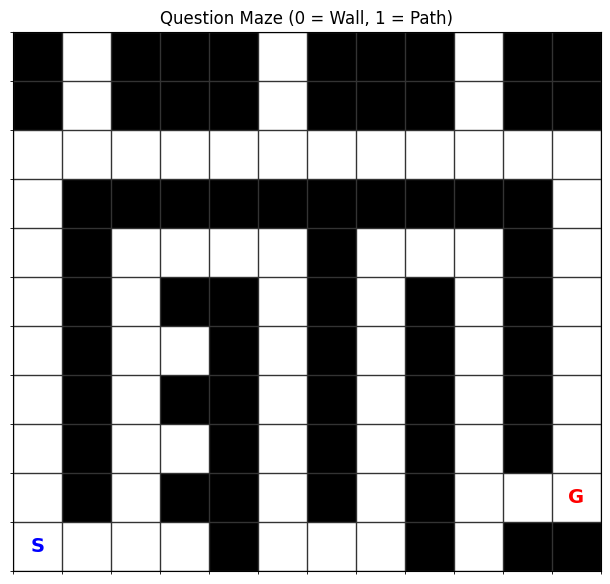

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Maze: 0 = Wall (Black), 1 = Path (White)
# I have inverted your original array so 0s are the "tally black" walls
maze = np.array([
    [0,1,0,0,0,1,0,0,0,1,0,0],
    [0,1,0,0,0,1,0,0,0,1,0,0],
    [1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,0,0,0,0,0,0,1],
    [1,0,1,1,1,1,0,1,1,1,0,1],
    [1,0,1,0,0,1,0,1,0,1,0,1],
    [1,0,1,1,0,1,0,1,0,1,0,1],
    [1,0,1,0,0,1,0,1,0,1,0,1],
    [1,0,1,1,0,1,0,1,0,1,0,1],
    [1,0,1,0,0,1,0,1,0,1,1,1],
    [1,1,1,1,0,1,1,1,0,1,0,0]
])

# Start and Goal are on Path nodes (1s)
start = (10, 0)
goal = (9, 11)
rows, cols = maze.shape

# Plotting the Question Maze
fig, ax = plt.subplots(figsize=(8, 7))
# Using cmap="gray" ensures 0 is Black and 1 is White
ax.imshow(maze, cmap="gray", interpolation="nearest")

# Formatting
ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
ax.grid(which="minor", color="#333333", linestyle="-", linewidth=1)
ax.text(start[1], start[0], "S", ha="center", va="center", color="blue", fontsize=14, fontweight="bold")
ax.text(goal[1], goal[0], "G", ha="center", va="center", color="red", fontsize=14, fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Question Maze (0 = Wall, 1 = Path)")
plt.show()

## Cell 2: Heuristic Function
### This function skips any node that is a wall (0).

In [10]:
def calculate_heuristics(maze_grid, target):
    """
    Calculates Manhattan distance for path nodes only.
    Returns a dictionary of {(r, c): value}
    """
    h_values = {}
    r_goal, c_goal = target
    
    for r in range(rows):
        for c in range(cols):
            # Only calculate if it is a path node (1)
            if maze_grid[r, c] == 1:
                distance = abs(r - r_goal) + abs(c - c_goal)
                h_values[(r, c)] = distance
            else:
                # Black nodes (0) get no heuristic value
                h_values[(r, c)] = None
                
    return h_values

# Generate the values
heuristic_results = calculate_heuristics(maze, goal)
print("Heuristic calculation complete. Walls (0) were ignored.")

Heuristic calculation complete. Walls (0) were ignored.


## Cell 3: Labeling and Displaying
### This cell renders the maze and overlays the values only on the path nodes.

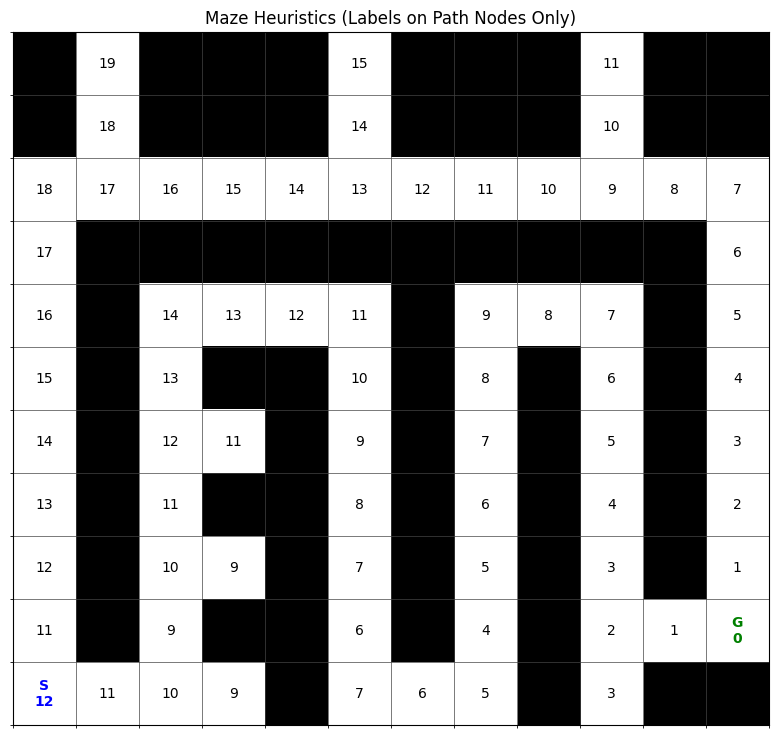

In [11]:
fig, ax = plt.subplots(figsize=(10, 9))

# Display Maze (0 is Black)
ax.imshow(maze, cmap="gray", interpolation="nearest")

# Grid styling
ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
ax.grid(which="minor", color="#444444", linestyle="-", linewidth=0.5)

# Labeling
for (r, c), val in heuristic_results.items():
    if val is not None:
        # Determine color for contrast (Goal is green, Start is blue, others black)
        color = "black"
        font_weight = "normal"
        
        display_text = str(val)
        
        if (r, c) == start:
            color, font_weight, display_text = "blue", "bold", f"S\n{val}"
        elif (r, c) == goal:
            color, font_weight, display_text = "green", "bold", f"G\n{val}"
            
        ax.text(c, r, display_text, ha="center", va="center", 
                color=color, fontsize=10, fontweight=font_weight)

ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Maze Heuristics (Labels on Path Nodes Only)")
plt.show()